In [ ]:
# 1. تثبيت المكتبة (إذا لم تكن موجودة)
!pip install kagglehub

import kagglehub
from kagglehub import KaggleDatasetAdapter

# 2. تحميل وقراءة ملف الـ CSV الرئيسي (بيانات الحالات)
# سنقوم بتحديد الملف 'stage_2_train_labels.csv'
file_path = "stage_2_train_labels.csv"

try:
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      "parin30/rsna-pneumonia-detection",
      file_path,
    )

    print("تم تحميل البيانات بنجاح!")
    print(df.head())
except Exception as e:
    print(f"حدث خطأ: {e}")

# 3. إذا كنت تريد معرفة مكان تخزين الصور (ملفات dcm) على جهاز الكولاب:
path = kagglehub.dataset_download("parin30/rsna-pneumonia-detection")
print(f"المسار الكامل للمجلد الذي يحتوي على كل البيانات: {path}")

/tmp/ipython-input-2345744672.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


حدث خطأ: 404 Client Error.

Resource not found at URL: https://www.kaggle.com/datasets/parin30/rsna-pneumonia-detection/versions/2
The server reported the following issues: Data not found
Please make sure you specified the correct resource identifiers.


100%|██████████| 3.66G/3.66G [02:49<00:00, 23.2MB/s]

Extracting files...


المسار الكامل للمجلد الذي يحتوي على كل البيانات: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2


In [ ]:
import os
import pandas as pd

# المسار الأساسي الذي وجدناه سابقاً
base_path = "/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2"
sub_folder = "drive-download-20240112T131344Z-002"

# المسار الجديد الذي سنبحث فيه
full_search_path = os.path.join(base_path, sub_folder)

print(f"جاري البحث داخل: {full_search_path}")

# استعراض كافة الملفات داخل المجلد الفرعي
try:
    files = os.listdir(full_search_path)
    print("الملفات الموجودة:")
    for f in files:
        print(f"- {f}")

    # محاولة البحث عن أي ملف ينتهي بـ .csv تلقائياً
    csv_files = [f for f in files if f.endswith('.csv')]

    if csv_files:
        csv_path = os.path.join(full_search_path, csv_files[0])
        print(f"\n✅ تم العثور على ملف: {csv_files[0]}")
        df = pd.read_csv(csv_path)
        display(df.head())
    else:
        print("\n❌ لم يتم العثور على أي ملف CSV داخل هذا المجلد.")

except Exception as e:
    print(f"حدث خطأ: {e}")

جاري البحث داخل: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002
الملفات الموجودة:
- stage_2_train_images
- GCP Credits Request Link - RSNA.txt
- stage_2_sample_submission.csv
- stage_2_test_images
- stage_2_train_labels.csv
- stage_2_detailed_class_info.csv

✅ تم العثور على ملف: stage_2_sample_submission.csv


,patientId,PredictionString
0,0000a175-0e68-4ca4-b1af-167204a7e0bc,0.5 0 0 100 100
1,0005d3cc-3c3f-40b9-93c3-46231c3eb813,0.5 0 0 100 100
2,000686d7-f4fc-448d-97a0-44fa9c5d3aa6,0.5 0 0 100 100
3,000e3a7d-c0ca-4349-bb26-5af2d8993c3d,0.5 0 0 100 100
4,00100a24-854d-423d-a092-edcf6179e061,0.5 0 0 100 100


In [ ]:
!pip -q install pydicom opencv-python pandas scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.3 MB/s eta 0:00:00


In [ ]:
import os, glob

def find_rsna_paths(root):
    # ابحث عن CSV labels
    csvs = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    label_csv = None
    for c in csvs:
        name = os.path.basename(c).lower()
        if "stage_2_train_labels" in name or "train_labels" in name:
            label_csv = c
            break

    # ابحث عن مجلد الصور DICOM
    dcm_dirs = []
    for p in glob.glob(os.path.join(root, "**"), recursive=True):
        if os.path.isdir(p):
            # افحص بسرعة: هل فيه ملفات dcm؟
            if len(glob.glob(os.path.join(p, "*.dcm"))) > 0:
                dcm_dirs.append(p)

    # اختر أكبر مجلد DICOM (غالبًا هو مجلد train_images)
    img_dir = None
    if dcm_dirs:
        img_dir = max(dcm_dirs, key=lambda d: len(glob.glob(os.path.join(d, "*.dcm"))))

    return label_csv, img_dir, csvs, dcm_dirs

DATA_ROOT = "/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2"

label_csv, img_dir, csvs, dcm_dirs = find_rsna_paths(DATA_ROOT)

print("Found CSV:", label_csv)
print("Found IMG_DIR:", img_dir)
print("\nAll CSVs (first 20):")
print(csvs[:20])
print("\nDICOM dirs found (first 10):")
print(dcm_dirs[:10])


Found CSV: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_labels.csv
Found IMG_DIR: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_images

All CSVs (first 20):
['/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_sample_submission.csv', '/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_labels.csv', '/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_detailed_class_info.csv']

DICOM dirs found (first 10):
['/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_images', '/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive

In [ ]:
# =========================================
# Cell 1/4: Setup + Drive + Paths
# =========================================

# (اختياري) إذا احتجت تثبيت
# !pip -q install pydicom opencv-python pandas scikit-learn tqdm

import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pydicom
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# =========================================
# Reproducibility
# =========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================================
# (Colab) Google Drive + Save paths
# =========================================
IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SAVE_DIR = "/content/drive/MyDrive/rsna_multitask_runs/run1" if IN_COLAB else "./rsna_multitask_runs/run1"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_CLS_PATH = os.path.join(SAVE_DIR, "best_by_auc.pth")
BEST_DET_PATH = os.path.join(SAVE_DIR, "best_by_iou.pth")
LAST_PATH     = os.path.join(SAVE_DIR, "last.pth")
HIST_CSV      = os.path.join(SAVE_DIR, "history.csv")

PLOT_TRAIN_LOSS      = os.path.join(SAVE_DIR, "plot_train_loss.png")
PLOT_TRAIN_PARTS     = os.path.join(SAVE_DIR, "plot_train_loss_parts.png")
PLOT_VAL_AUC         = os.path.join(SAVE_DIR, "plot_val_auc.png")
PLOT_VAL_IOU         = os.path.join(SAVE_DIR, "plot_val_iou.png")

print("IN_COLAB:", IN_COLAB)
print("SAVE_DIR:", SAVE_DIR)

# =========================================
# Dataset paths (EDIT THESE)
# =========================================
DATA_ROOT = "/root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002"
IMG_DIR   = os.path.join(DATA_ROOT, "stage_2_train_images")
CSV_PATH  = os.path.join(DATA_ROOT, "stage_2_train_labels.csv")


print("IMG_DIR:", IMG_DIR)
print("CSV_PATH:", CSV_PATH)


Device: cuda
IN_COLAB: False
SAVE_DIR: ./rsna_multitask_runs/run1
IMG_DIR: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_images
CSV_PATH: /root/.cache/kagglehub/datasets/parin30/rsna-pneumonia-detection/versions/2/drive-download-20240112T131344Z-002/stage_2_train_labels.csv


In [ ]:
# =========================================
# Cell 2/4: Load CSV + Build index + Dataset + Loaders
# =========================================

# Load CSV + Build index by patientId
df = pd.read_csv(CSV_PATH)

patient_ids = df["patientId"].unique().tolist()

boxes_by_pid = {}
target_by_pid = {}

for pid, g in df.groupby("patientId"):
    g1 = g[g["Target"] == 1]
    if len(g1) == 0:
        target_by_pid[pid] = 0
        boxes_by_pid[pid] = []
    else:
        target_by_pid[pid] = 1
        b = g1[["x","y","width","height"]].values.astype(np.float32)
        boxes_by_pid[pid] = b

train_pids, val_pids = train_test_split(
    patient_ids,
    test_size=0.15,
    random_state=42,
    stratify=[target_by_pid[pid] for pid in patient_ids]
)

print("Train:", len(train_pids), "Val:", len(val_pids))
print("Pos rate train:", np.mean([target_by_pid[p] for p in train_pids]))
print("Pos rate val:", np.mean([target_by_pid[p] for p in val_pids]))

# =========================================
# DICOM reader + preprocessing
# =========================================
def read_dicom(path):
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)
    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    return img

def resize_and_boxes(img, boxes_xywh, out_size=512):
    h, w = img.shape
    img_resized = cv2.resize(img, (out_size, out_size), interpolation=cv2.INTER_LINEAR)

    if len(boxes_xywh) == 0:
        return img_resized, np.zeros((0,4), dtype=np.float32)

    scale_x = out_size / w
    scale_y = out_size / h

    boxes = []
    for x,y,bw,bh in boxes_xywh:
        x1 = x * scale_x
        y1 = y * scale_y
        x2 = (x + bw) * scale_x
        y2 = (y + bh) * scale_y
        boxes.append([x1,y1,x2,y2])
    return img_resized, np.array(boxes, dtype=np.float32)

# =========================================
# Dataset + collate
# =========================================
class RSNAMultiTaskDataset(Dataset):
    def __init__(self, pids, img_dir, boxes_by_pid, target_by_pid, out_size=512, augment=False):
        self.pids = pids
        self.img_dir = img_dir
        self.boxes_by_pid = boxes_by_pid
        self.target_by_pid = target_by_pid
        self.out_size = out_size
        self.augment = augment

    def __len__(self):
        return len(self.pids)

    def _augment(self, img, boxes):
        if random.random() < 0.5:
            img = img[:, ::-1].copy()
            if boxes.shape[0] > 0:
                x1 = boxes[:,0].copy()
                x2 = boxes[:,2].copy()
                boxes[:,0] = self.out_size - x2
                boxes[:,2] = self.out_size - x1

        if random.random() < 0.7:
            alpha = 1.0 + random.uniform(-0.1, 0.1)
            beta  = random.uniform(-0.05, 0.05)
            img = np.clip(img * alpha + beta, 0.0, 1.0)

        return img, boxes

    def __getitem__(self, idx):
        pid = self.pids[idx]
        dcm_path = os.path.join(self.img_dir, f"{pid}.dcm")

        img = read_dicom(dcm_path)
        boxes_xywh = self.boxes_by_pid[pid]
        img, boxes = resize_and_boxes(img, boxes_xywh, out_size=self.out_size)

        if self.augment:
            img, boxes = self._augment(img, boxes)

        img_t = torch.from_numpy(img).unsqueeze(0).float()
        cls = torch.tensor([self.target_by_pid[pid]], dtype=torch.float32)

        return img_t, cls, torch.from_numpy(boxes).float()

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    cls  = torch.stack([b[1] for b in batch], dim=0)
    boxes = [b[2] for b in batch]
    return imgs, cls, boxes

# =========================================
# Prepare loaders
# =========================================
OUT_SIZE = 512
STRIDE = 32
BATCH = 8

train_ds = RSNAMultiTaskDataset(train_pids, IMG_DIR, boxes_by_pid, target_by_pid, out_size=OUT_SIZE, augment=True)
val_ds   = RSNAMultiTaskDataset(val_pids, IMG_DIR, boxes_by_pid, target_by_pid, out_size=OUT_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True)

print("Loaders ready ✅")


Train: 22681 Val: 4003
Pos rate train: 0.22529870816983377
Pos rate val: 0.22533100174868848
Loaders ready ✅


In [ ]:
# =========================================
# Cell 3/4
# الهدف من هذه الخلية:
# 1) بناء شبكة من الصفر MultiTaskNet (تصنيف + كشف).
# 2) تعريف طريقة تحويل الـ GT Boxes إلى Targets على Grid (make_det_targets).
# 3) تعريف Loss متعددة المهام (تصنيف + objectness + box).
# 4) تعريف أدوات فكّ التنبؤات إلى boxes + NMS.
# 5) تعريف train/eval وحفظ checkpoints.
# =========================================


# -------------------------------------------------
# (A) ConvBlock: بلوك تلافيفي قياسي
# لماذا؟
# - نحتاج تكرار Conv+BN+ReLU كثيرًا في backbone، فنسوي بلوك واحد قابل لإعادة الاستخدام.
# - BN يساعد استقرار التدريب، ReLU يعطي لاخطية.
# -------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


# -------------------------------------------------
# (B) MultiTaskNet: الشبكة من الصفر (Multi-Task)
# الفكرة:
# - Backbone يضغط الصورة تدريجيًا إلى Grid صغيرة (مثلاً 16×16).
# - 3 Heads:
#   1) cls_head: قرار على مستوى الصورة (Pneumonia / No).
#   2) det_obj : objectness على مستوى كل خلية Grid.
#   3) det_ltrb: 4 قيم (L,T,R,B) لكل خلية لتحديد الصندوق.
#
# ملاحظة مهمة:
# - نستخدم Softplus على ltrb لضمان الإيجابية (هذه “مسافات” فلا تكون سالبة).
# - نُمثل ltrb بوحدات stride-units (ltrb/stride) لتوحيد المقياس وتجنب IoU=0.
# -------------------------------------------------
class MultiTaskNet(nn.Module):
    def __init__(self, in_ch=1, base=32, grid_stride=32):
        super().__init__()
        self.grid_stride = grid_stride

        # Backbone
        self.stem = nn.Sequential(
            ConvBlock(in_ch, base),
            ConvBlock(base, base),
        )
        self.down1 = nn.Sequential(ConvBlock(base, base * 2, s=2), ConvBlock(base * 2, base * 2))
        self.down2 = nn.Sequential(ConvBlock(base * 2, base * 4, s=2), ConvBlock(base * 4, base * 4))
        self.down3 = nn.Sequential(ConvBlock(base * 4, base * 8, s=2), ConvBlock(base * 8, base * 8))
        self.down4 = nn.Sequential(ConvBlock(base * 8, base * 8, s=2), ConvBlock(base * 8, base * 8))
        self.down5 = nn.Sequential(ConvBlock(base * 8, base * 8, s=2), ConvBlock(base * 8, base * 8))

        # Heads
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base * 8, 1)
        )
        self.det_obj = nn.Conv2d(base * 8, 1, kernel_size=1)
        self.det_ltrb = nn.Conv2d(base * 8, 4, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        # تهيئة الأوزان لأننا نتدرب من الصفر
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.down4(x)
        feat = self.down5(x)

        cls_logit = self.cls_head(feat)        # [B,1]
        obj_logit = self.det_obj(feat)         # [B,1,G,G]

        # ltrb بوحدات stride-units لضبط المقياس
        ltrb_raw = self.det_ltrb(feat)         # [B,4,G,G]
        ltrb = F.softplus(ltrb_raw)            # ضمان الإيجابية

        return cls_logit, obj_logit, ltrb


# -------------------------------------------------
# (C) make_det_targets: تحويل GT Boxes -> Targets على Grid
# لماذا؟
# - الكشف هنا Grid-based: لكل خلية نحدد هل توجد منطقة مرض (obj_t).
# - إذا كانت الخلية موجبة: نخزن ltrb (مسافات من مركز الخلية لحدود الصندوق).
#
# القاعدة:
# - نختار الخلية التي يقع فيها "مركز الصندوق".
# - نخزن ltrb بوحدات stride-units = (ltrb_pixels / stride).
# -------------------------------------------------
def make_det_targets(boxes_xyxy, out_size=512, stride=32):
    G = out_size // stride
    obj_t = torch.zeros((G, G), dtype=torch.float32)
    ltrb_t = torch.zeros((4, G, G), dtype=torch.float32)
    pos_mask = torch.zeros((G, G), dtype=torch.bool)

    if boxes_xyxy.numel() == 0:
        return obj_t, ltrb_t, pos_mask

    for b in boxes_xyxy:
        x1, y1, x2, y2 = b.tolist()
        cx, cy = 0.5 * (x1 + x2), 0.5 * (y1 + y2)

        gi = int(cx // stride)
        gj = int(cy // stride)
        gi = max(0, min(G - 1, gi))
        gj = max(0, min(G - 1, gj))

        ccx = (gi + 0.5) * stride
        ccy = (gj + 0.5) * stride

        # مسافات بالبكسل من مركز الخلية إلى حدود الصندوق
        l = max(0.0, ccx - x1)
        t = max(0.0, ccy - y1)
        r = max(0.0, x2 - ccx)
        btm = max(0.0, y2 - ccy)

        # تحويل إلى stride-units لتثبيت المقياس
        ltrb_units = torch.tensor([l, t, r, btm], dtype=torch.float32) / float(stride)

        # إذا أكثر من صندوق بنفس الخلية، نحتفظ بالأكبر (تقريبًا)
        if obj_t[gj, gi] == 0:
            obj_t[gj, gi] = 1.0
            ltrb_t[:, gj, gi] = ltrb_units
            pos_mask[gj, gi] = True
        else:
            old = ltrb_t[:, gj, gi]
            old_area = (old[0] + old[2]) * (old[1] + old[3])
            new_area = (ltrb_units[0] + ltrb_units[2]) * (ltrb_units[1] + ltrb_units[3])
            if new_area > old_area:
                ltrb_t[:, gj, gi] = ltrb_units
                pos_mask[gj, gi] = True

    return obj_t, ltrb_t, pos_mask


# -------------------------------------------------
# (D) MultiTaskLoss: خسارة متعددة المهام
# ماذا بداخلها؟
# 1) loss_cls: BCEWithLogits للتصنيف (مع pos_weight لأن الإيجابيات قليلة).
# 2) loss_obj: BCEWithLogits للـ objectness مع pos_weight ديناميكي بسبب عدم التوازن الكبير في Grid.
# 3) loss_box: SmoothL1 على ltrb فقط للخلايا الموجبة pos_mask.
# -------------------------------------------------
class MultiTaskLoss(nn.Module):
    def __init__(self, pos_weight_cls=3.0, lambda_cls=1.0, lambda_det=1.0, obj_pos_weight_max=200.0):
        super().__init__()
        self.bce_cls = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_cls]))
        self.lambda_cls = lambda_cls
        self.lambda_det = lambda_det
        self.obj_pos_weight_max = obj_pos_weight_max

    def forward(self, cls_logit, obj_logit, ltrb_pred, cls_t, det_targets):
        # (1) Classification
        loss_cls = self.bce_cls(cls_logit, cls_t)

        # (2) Stack detection targets
        obj_t = torch.stack([t[0] for t in det_targets], dim=0).to(cls_logit.device)      # [B,G,G]
        ltrb_t = torch.stack([t[1] for t in det_targets], dim=0).to(cls_logit.device)     # [B,4,G,G]
        pos_mask = torch.stack([t[2] for t in det_targets], dim=0).to(cls_logit.device)   # [B,G,G]

        # (3) Objectness imbalance handling (dynamic pos_weight)
        obj_logit_ = obj_logit.squeeze(1)  # [B,G,G]
        pos = obj_t.sum()
        neg = obj_t.numel() - pos
        pos_weight = (neg / (pos + 1e-6)).clamp(min=1.0, max=self.obj_pos_weight_max)
        loss_obj = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(obj_logit_, obj_t)

        # (4) Box regression on positive cells only
        if pos_mask.any():
            pred_pos = ltrb_pred.permute(0, 2, 3, 1)[pos_mask]  # [Npos,4]
            tgt_pos = ltrb_t.permute(0, 2, 3, 1)[pos_mask]      # [Npos,4]
            loss_box = F.smooth_l1_loss(pred_pos, tgt_pos)
        else:
            loss_box = torch.tensor(0.0, device=cls_logit.device)

        loss_det = loss_obj + loss_box
        loss_total = self.lambda_cls * loss_cls + self.lambda_det * loss_det

        return loss_total, {"cls": loss_cls.item(), "obj": loss_obj.item(), "box": float(loss_box.item())}


# -------------------------------------------------
# (E) Decoding + NMS
# - decode_boxes: يحول (obj_logit + ltrb_pred) إلى صناديق xyxy في البكسل.
#   ملاحظة: لأن ltrb بوحدات stride-units، نضربها في stride عند decoding.
# - nms: إزالة الصناديق المكررة المتداخلة.
# -------------------------------------------------
def decode_boxes(obj_logit, ltrb_pred, out_size=512, stride=32, conf_th=0.5):
    G = out_size // stride
    obj = torch.sigmoid(obj_logit).squeeze(0)  # [G,G]

    boxes, scores = [], []
    for gj in range(G):
        for gi in range(G):
            s = obj[gj, gi].item()
            if s < conf_th:
                continue

            ccx = (gi + 0.5) * stride
            ccy = (gj + 0.5) * stride

            # stride-units -> pixels
            l, t, r, b = (ltrb_pred[:, gj, gi] * float(stride))

            x1 = max(0.0, ccx - l.item())
            y1 = max(0.0, ccy - t.item())
            x2 = min(out_size, ccx + r.item())
            y2 = min(out_size, ccy + b.item())

            boxes.append([x1, y1, x2, y2])
            scores.append(s)

    if len(boxes) == 0:
        return torch.zeros((0, 4)), torch.zeros((0,))
    return torch.tensor(boxes), torch.tensor(scores)


def nms(boxes, scores, iou_th=0.4):
    if boxes.numel() == 0:
        return []

    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    order = scores.argsort(descending=True)

    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]

        xx1 = torch.maximum(x1[i], x1[rest])
        yy1 = torch.maximum(y1[i], y1[rest])
        xx2 = torch.minimum(x2[i], x2[rest])
        yy2 = torch.minimum(y2[i], y2[rest])

        inter = (xx2 - xx1).clamp(min=0) * (yy2 - yy1).clamp(min=0)
        iou = inter / (areas[i] + areas[rest] - inter + 1e-6)

        order = rest[iou <= iou_th]

    return keep


# -------------------------------------------------
# (F) Train/Eval + Checkpoints
# - train_one_epoch: يبني det_targets لكل صورة ثم يحسب loss ويحدث الأوزان.
# - evaluate: يحسب AUC للتصنيف + mean best IoU للكشف بعد decode + NMS.
# - save/load checkpoint: حفظ/استرجاع التدريب.
# -------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, out_size=512, stride=32):
    model.train()
    running = {"loss": 0.0, "cls": 0.0, "obj": 0.0, "box": 0.0}
    n = 0

    for imgs, cls_t, boxes_list in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        cls_t = cls_t.to(device)

        det_targets = []
        for boxes in boxes_list:
            obj_t, ltrb_t, pos_mask = make_det_targets(boxes, out_size=out_size, stride=stride)
            det_targets.append((obj_t, ltrb_t, pos_mask))

        cls_logit, obj_logit, ltrb_pred = model(imgs)
        loss, parts = criterion(cls_logit, obj_logit, ltrb_pred, cls_t, det_targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        running["loss"] += loss.item() * bs
        running["cls"] += parts["cls"] * bs
        running["obj"] += parts["obj"] * bs
        running["box"] += parts["box"] * bs
        n += bs

    for k in running:
        running[k] /= max(1, n)
    return running


@torch.no_grad()
def evaluate(model, loader, out_size=512, stride=32, conf_th=0.3):
    model.eval()
    y_true, y_prob = [], []
    iou_list = []

    for imgs, cls_t, boxes_list in tqdm(loader, desc="Val", leave=False):
        imgs = imgs.to(device)
        cls_logit, obj_logit, ltrb_pred = model(imgs)

        probs = torch.sigmoid(cls_logit).detach().cpu().numpy().reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(cls_t.numpy().reshape(-1).tolist())

        B = imgs.size(0)
        for i in range(B):
            gt = boxes_list[i]
            if gt.numel() == 0:
                continue

            boxes_pred, scores = decode_boxes(
                obj_logit[i].cpu(), ltrb_pred[i].cpu(),
                out_size=out_size, stride=stride, conf_th=conf_th
            )
            if boxes_pred.numel() == 0:
                iou_list.append(0.0)
                continue

            keep = nms(boxes_pred, scores, iou_th=0.4)
            boxes_pred = boxes_pred[keep]

            best = 0.0
            for p in boxes_pred:
                px1, py1, px2, py2 = p
                p_area = max(0.0, (px2 - px1).item()) * max(0.0, (py2 - py1).item())
                for g in gt:
                    gx1, gy1, gx2, gy2 = g
                    inter_x1 = max(px1.item(), gx1.item())
                    inter_y1 = max(py1.item(), gy1.item())
                    inter_x2 = min(px2.item(), gx2.item())
                    inter_y2 = min(py2.item(), gy2.item())
                    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
                    g_area = max(0.0, (gx2 - gx1).item()) * max(0.0, (gy2 - gy1).item())
                    iou = inter / (p_area + g_area - inter + 1e-6)
                    best = max(best, iou)

            iou_list.append(best)

    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan")
    mean_iou = float(np.mean(iou_list)) if len(iou_list) else 0.0
    return {"auc_cls": float(auc), "mean_best_iou_det": mean_iou}


def save_checkpoint(path, model, optimizer, epoch, best_metrics, extra=None):
    ckpt = {
        "epoch": int(epoch),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "best_metrics": best_metrics,
        "extra": extra or {},
    }
    torch.save(ckpt, path)


def load_checkpoint(path, model, optimizer=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and ckpt.get("optimizer_state") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


print("Model/Loss/Utils ready ✅")


Model/Loss/Utils ready ✅


Epoch 1/5 | LR=1.00e-03 | conf=0.01 | Train loss=1.5581 (cls=0.9125, obj=0.3370, box=0.3086) | Val AUC=0.5244 | Val IoU(thr)=0.4057 | Val IoU@TopK10=0.0008 | obj(sigmoid) min/mean/max=0.0000/0.0303/0.9184
✅ Saved BEST (by AUC) -> ./rsna_multitask_runs/run1/best_by_auc.pth
✅ Saved BEST (by IoU threshold) -> ./rsna_multitask_runs/run1/best_by_iou.pth
✅ Saved BEST (by IoU TopK10) -> ./rsna_multitask_runs/run1/best_by_iou_topk10.pth


Epoch 2/5 | LR=1.00e-03 | conf=0.01 | Train loss=1.3654 (cls=0.8510, obj=0.2587, box=0.2557) | Val AUC=0.8332 | Val IoU(thr)=0.5854 | Val IoU@TopK10=0.0014 | obj(sigmoid) min/mean/max=0.0000/0.0745/0.9422
✅ Saved BEST (by AUC) -> ./rsna_multitask_runs/run1/best_by_auc.pth
✅ Saved BEST (by IoU threshold) -> ./rsna_multitask_runs/run1/best_by_iou.pth
✅ Saved BEST (by IoU TopK10) -> ./rsna_multitask_runs/run1/best_by_iou_topk10.pth


Epoch 3/5 | LR=1.00e-03 | conf=0.05 | Train loss=1.2820 (cls=0.8136, obj=0.2255, box=0.2429) | Val AUC=0.8432 | Val IoU(thr)=0.5899 | Val IoU@TopK10=0.0016 | obj(sigmoid) min/mean/max=0.0000/0.0553/0.9378
✅ Saved BEST (by AUC) -> ./rsna_multitask_runs/run1/best_by_auc.pth
✅ Saved BEST (by IoU threshold) -> ./rsna_multitask_runs/run1/best_by_iou.pth
✅ Saved BEST (by IoU TopK10) -> ./rsna_multitask_runs/run1/best_by_iou_topk10.pth


Epoch 4/5 | LR=1.00e-03 | conf=0.05 | Train loss=1.2136 (cls=0.7919, obj=0.1997, box=0.2220) | Val AUC=0.8429 | Val IoU(thr)=0.5892 | Val IoU@TopK10=0.0014 | obj(sigmoid) min/mean/max=0.0000/0.0381/0.9129


Epoch 5/5 | LR=1.00e-03 | conf=0.10 | Train loss=1.1733 (cls=0.7738, obj=0.1866, box=0.2129) | Val AUC=0.8529 | Val IoU(thr)=0.5964 | Val IoU@TopK10=0.0014 | obj(sigmoid) min/mean/max=0.0000/0.0506/0.9622
✅ Saved BEST (by AUC) -> ./rsna_multitask_runs/run1/best_by_auc.pth
✅ Saved BEST (by IoU threshold) -> ./rsna_multitask_runs/run1/best_by_iou.pth
Saved history -> ./rsna_multitask_runs/run1/history.csv
Saved plots ->
 - ./rsna_multitask_runs/run1/plot_train_loss.png
 - ./rsna_multitask_runs/run1/plot_train_loss_parts.png
 - ./rsna_multitask_runs/run1/plot_val_auc.png
 - ./rsna_multitask_runs/run1/plot_val_iou.png
 - ./rsna_multitask_runs/run1/plot_val_iou_topk10.png
Done ✅


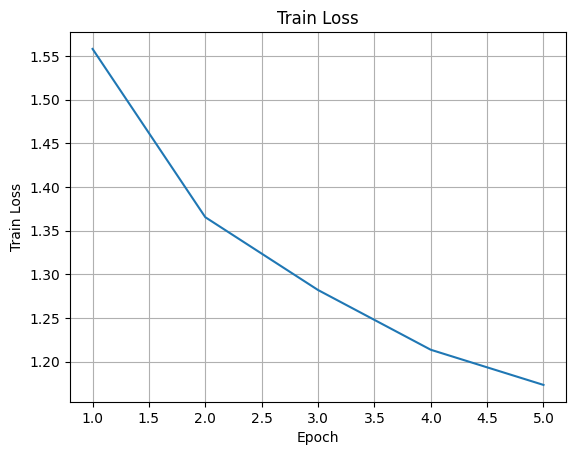

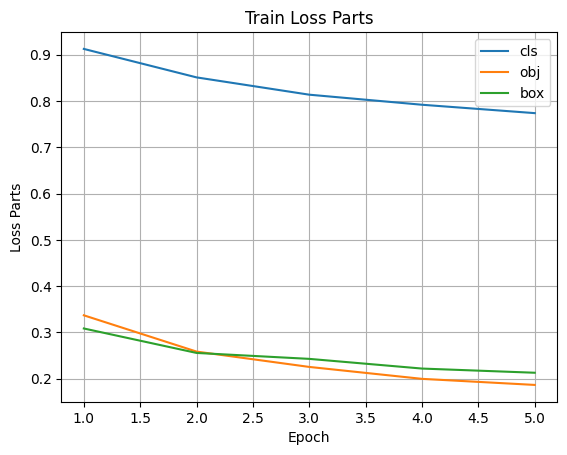

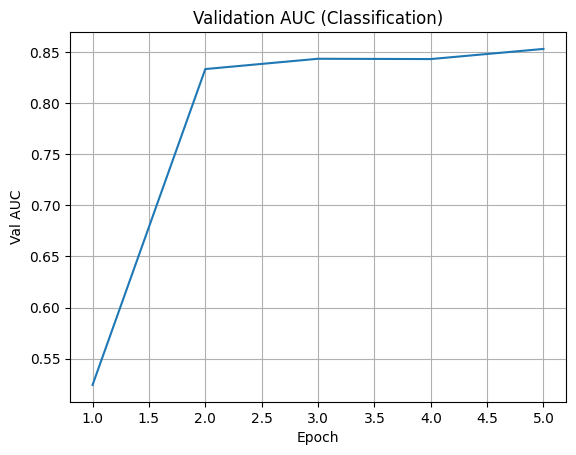

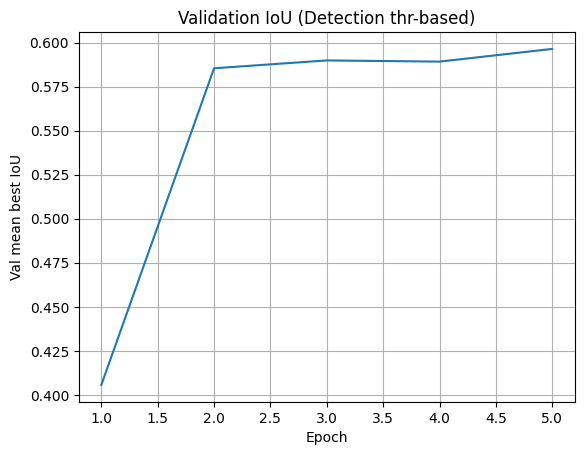

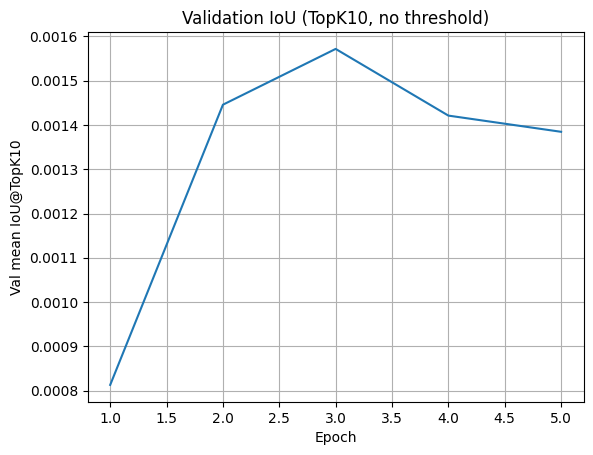

In [ ]:
# =========================================
# Cell 4/4
# الهدف من هذه الخلية:
# 1) إعداد التدريب (model/loss/optimizer/scheduler/early stopping).
# 2) تشغيل training loop وتسجيل history.
# 3) حفظ أفضل نماذج حسب AUC و IoU.
# 4) رسم منحنيات التدريب.
# 5) إضافة دالة inference لصورة واحدة DICOM.
# =========================================

EPOCHS = 5
LR = 1e-3

# -------------------------------------------------
# (A) إنشاء النموذج وحساب pos_weight للتصنيف
# لماذا pos_weight؟
# لأن بيانات RSNA غير متوازنة: صور سلبية أكثر من الإيجابية.
# -------------------------------------------------
model = MultiTaskNet(in_ch=1, base=32, grid_stride=STRIDE).to(device)

pos_rate = np.mean([target_by_pid[p] for p in train_pids])
pos_weight = (1 - pos_rate) / (pos_rate + 1e-6)

criterion = MultiTaskLoss(
    pos_weight_cls=float(pos_weight),
    lambda_cls=1.0,
    lambda_det=1.0
).to(device)

# -------------------------------------------------
# (B) Optimizer + Scheduler
# AdamW: مناسب جدًا للتدريب من الصفر
# ReduceLROnPlateau: يقلل LR إذا توقف تحسن AUC
# -------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

# -------------------------------------------------
# (C) Early stopping على AUC (لتجنب overfitting)
# -------------------------------------------------
EARLY_STOP_PATIENCE = 3
no_improve = 0
best_auc = -1.0
best_iou = -1.0
best_iou_topk = -1.0
history = []


# -------------------------------------------------
# (D) Helpers لتقييم TopK (تشخيصي)
# لماذا TopK؟
# أحيانًا النموذج يتعلم الصندوق لكن scores منخفضة في البداية،
# فالـ threshold-based IoU يظهر سيء. TopK يقيس "هل المكان يتحسن؟".
# -------------------------------------------------
def box_iou_xyxy(a, b, eps=1e-6):
    ax1, ay1, ax2, ay2 = [float(x) for x in a]
    bx1, by1, bx2, by2 = [float(x) for x in b]
    inter_x1 = max(ax1, bx1); inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2); inter_y2 = min(ay2, by2)
    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    return inter / (area_a + area_b - inter + eps)


def decode_topk(obj_logit_1, ltrb_pred_4, out_size=512, stride=32, topk=10):
    # نأخذ أعلى K خلايا حسب objectness ثم نحولها لصناديق
    if obj_logit_1.dim() == 3:
        obj_logit_1 = obj_logit_1.squeeze(0)
    obj = torch.sigmoid(obj_logit_1)

    G = out_size // stride
    flat = obj.reshape(-1)
    k = min(topk, flat.numel())
    vals, idxs = torch.topk(flat, k)

    boxes, scores = [], []
    for v, idx in zip(vals, idxs):
        gj = int((idx // G).item())
        gi = int((idx % G).item())

        ccx = (gi + 0.5) * stride
        ccy = (gj + 0.5) * stride

        # إذا ltrb_pred بوحدات stride-units في Cell3: لازم نضرب في stride هنا أيضًا
        l, t, r, b = (ltrb_pred_4[:, gj, gi] * float(stride))

        x1 = max(0.0, ccx - float(l.item()))
        y1 = max(0.0, ccy - float(t.item()))
        x2 = min(out_size, ccx + float(r.item()))
        y2 = min(out_size, ccy + float(b.item()))

        boxes.append([x1, y1, x2, y2])
        scores.append(float(v.item()))

    if len(boxes) == 0:
        return torch.zeros((0, 4)), torch.zeros((0,))
    return torch.tensor(boxes), torch.tensor(scores)


@torch.no_grad()
def evaluate_topk_iou(model, loader, out_size=512, stride=32, topk=10):
    model.eval()
    iou_list = []
    for imgs, cls_t, boxes_list in tqdm(loader, desc=f"ValTopK@{topk}", leave=False):
        imgs = imgs.to(device)
        _, obj_logit, ltrb_pred = model(imgs)

        for i in range(imgs.size(0)):
            gt = boxes_list[i]
            if gt.numel() == 0:
                continue

            boxes_pred, _ = decode_topk(
                obj_logit[i].detach().cpu(),
                ltrb_pred[i].detach().cpu(),
                out_size=out_size, stride=stride, topk=topk
            )
            if boxes_pred.numel() == 0:
                iou_list.append(0.0)
                continue

            best = 0.0
            for p in boxes_pred:
                for g in gt:
                    best = max(best, box_iou_xyxy(p.tolist(), g.tolist()))
            iou_list.append(best)

    return float(np.mean(iou_list)) if len(iou_list) else 0.0


@torch.no_grad()
def obj_score_stats(model, loader, batches=1):
    model.eval()
    for bi, (imgs, _, _) in enumerate(loader):
        if bi >= batches:
            break
        imgs = imgs.to(device)
        _, obj_logit, _ = model(imgs)
        obj = torch.sigmoid(obj_logit).detach().cpu()
        return float(obj.min()), float(obj.mean()), float(obj.max())
    return 0.0, 0.0, 0.0


# -------------------------------------------------
# (E) Training loop
# - نستخدم conf_th منخفض في البداية لأن النموذج يتنبأ بثقة ضعيفة أول التدريب.
# - نحفظ last دائمًا، وأفضل نموذج حسب AUC و IoU.
# -------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    if epoch <= 2:
        eval_conf = 0.01
    elif epoch <= 4:
        eval_conf = 0.05
    else:
        eval_conf = 0.10

    tr = train_one_epoch(model, train_loader, optimizer, criterion, out_size=OUT_SIZE, stride=STRIDE)
    va = evaluate(model, val_loader, out_size=OUT_SIZE, stride=STRIDE, conf_th=eval_conf)
    va_topk = evaluate_topk_iou(model, val_loader, out_size=OUT_SIZE, stride=STRIDE, topk=10)
    obj_min, obj_mean, obj_max = obj_score_stats(model, val_loader, batches=1)

    lr_now = optimizer.param_groups[0]["lr"]
    row = {
        "epoch": epoch,
        "lr": lr_now,
        "train_loss": tr["loss"],
        "train_cls": tr["cls"],
        "train_obj": tr["obj"],
        "train_box": tr["box"],
        "val_auc_cls": va["auc_cls"],
        "val_mean_best_iou_det": va["mean_best_iou_det"],
        "val_mean_iou_topk10": va_topk,
        "eval_conf": eval_conf,
        "obj_sigmoid_min": obj_min,
        "obj_sigmoid_mean": obj_mean,
        "obj_sigmoid_max": obj_max,
    }
    history.append(row)

    print(
        f"Epoch {epoch}/{EPOCHS} | LR={lr_now:.2e} | conf={eval_conf:.2f} | "
        f"Train loss={tr['loss']:.4f} (cls={tr['cls']:.4f}, obj={tr['obj']:.4f}, box={tr['box']:.4f}) | "
        f"Val AUC={va['auc_cls']:.4f} | Val IoU(thr)={va['mean_best_iou_det']:.4f} | Val IoU@TopK10={va_topk:.4f} | "
        f"obj(sigmoid) min/mean/max={obj_min:.4f}/{obj_mean:.4f}/{obj_max:.4f}"
    )

    # حفظ آخر نموذج
    save_checkpoint(
        LAST_PATH, model, optimizer, epoch,
        best_metrics={"best_auc": best_auc, "best_iou": best_iou, "best_iou_topk10": best_iou_topk},
        extra={"row": row}
    )

    improved_auc = False

    # أفضل حسب AUC
    if va["auc_cls"] > best_auc:
        best_auc = va["auc_cls"]
        save_checkpoint(
            BEST_CLS_PATH, model, optimizer, epoch,
            best_metrics={"best_auc": best_auc, "best_iou": best_iou, "best_iou_topk10": best_iou_topk},
            extra={"selection": "best_by_auc", "row": row}
        )
        print("✅ Saved BEST (by AUC) ->", BEST_CLS_PATH)
        improved_auc = True

    # أفضل حسب IoU (threshold-based)
    if va["mean_best_iou_det"] > best_iou:
        best_iou = va["mean_best_iou_det"]
        save_checkpoint(
            BEST_DET_PATH, model, optimizer, epoch,
            best_metrics={"best_auc": best_auc, "best_iou": best_iou, "best_iou_topk10": best_iou_topk},
            extra={"selection": "best_by_iou(threshold)", "row": row}
        )
        print("✅ Saved BEST (by IoU threshold) ->", BEST_DET_PATH)

    # أفضل حسب TopK (تشخيصي)
    if va_topk > best_iou_topk:
        best_iou_topk = va_topk
        BEST_DET_TOPK_PATH = os.path.join(SAVE_DIR, "best_by_iou_topk10.pth")
        save_checkpoint(
            BEST_DET_TOPK_PATH, model, optimizer, epoch,
            best_metrics={"best_auc": best_auc, "best_iou": best_iou, "best_iou_topk10": best_iou_topk},
            extra={"selection": "best_by_iou_topk10", "row": row}
        )
        print("✅ Saved BEST (by IoU TopK10) ->", BEST_DET_TOPK_PATH)

    # Scheduler على AUC
    scheduler.step(va["auc_cls"])

    # Early stopping
    if improved_auc:
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"⛔ Early stopping (no AUC improvement for {EARLY_STOP_PATIENCE} epochs).")
            break


# -------------------------------------------------
# (F) حفظ history والرسوم
# -------------------------------------------------
hist_df = pd.DataFrame(history)
hist_df.to_csv(HIST_CSV, index=False)
print("Saved history ->", HIST_CSV)

if len(hist_df):
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["train_loss"])
    plt.xlabel("Epoch"); plt.ylabel("Train Loss"); plt.title("Train Loss")
    plt.grid(True)
    plt.savefig(PLOT_TRAIN_LOSS, bbox_inches="tight", dpi=200)

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["train_cls"], label="cls")
    plt.plot(hist_df["epoch"], hist_df["train_obj"], label="obj")
    plt.plot(hist_df["epoch"], hist_df["train_box"], label="box")
    plt.xlabel("Epoch"); plt.ylabel("Loss Parts"); plt.title("Train Loss Parts")
    plt.grid(True); plt.legend()
    plt.savefig(PLOT_TRAIN_PARTS, bbox_inches="tight", dpi=200)

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_auc_cls"])
    plt.xlabel("Epoch"); plt.ylabel("Val AUC"); plt.title("Validation AUC (Classification)")
    plt.grid(True)
    plt.savefig(PLOT_VAL_AUC, bbox_inches="tight", dpi=200)

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_mean_best_iou_det"])
    plt.xlabel("Epoch"); plt.ylabel("Val mean best IoU"); plt.title("Validation IoU (Detection thr-based)")
    plt.grid(True)
    plt.savefig(PLOT_VAL_IOU, bbox_inches="tight", dpi=200)

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_mean_iou_topk10"])
    plt.xlabel("Epoch"); plt.ylabel("Val mean IoU@TopK10"); plt.title("Validation IoU (TopK10, no threshold)")
    plt.grid(True)
    plt.savefig(os.path.join(SAVE_DIR, "plot_val_iou_topk10.png"), bbox_inches="tight", dpi=200)

print("Done ✅")


# -------------------------------------------------
# (G) Inference helper: تجربة على DICOM واحدة
# - نقرأ DICOM
# - resize
# - نخرج cls_prob + boxes بعد NMS
# -------------------------------------------------
def infer_one_dicom(dcm_path, conf_th=0.3):
    model.eval()
    img = read_dicom(dcm_path)
    img, _ = resize_and_boxes(img, [], out_size=OUT_SIZE)

    x = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        cls_logit, obj_logit, ltrb_pred = model(x)
        cls_prob = torch.sigmoid(cls_logit)[0, 0].item()

        boxes_pred, scores = decode_boxes(
            obj_logit[0].detach().cpu(),
            ltrb_pred[0].detach().cpu(),
            out_size=OUT_SIZE, stride=STRIDE, conf_th=conf_th
        )
        if boxes_pred.numel() > 0:
            keep = nms(boxes_pred, scores, iou_th=0.4)
            boxes_pred = boxes_pred[keep]
            scores = scores[keep]

    return cls_prob, boxes_pred, scores


[DATA] Train positives ~ 114/500 (0.228)
[DATA] Val positives   ~ 108/500 (0.216)
[DATA] Found 902 positive val samples with boxes.

[SAMPLE idx=2668] cls=1.0  boxes=2
  boxes min (x1,y1,x2,y2): [ 60.5 212.  204.  431.5]
  boxes max (x1,y1,x2,y2): [235.  224.  414.  434.5]
  ✅ Boxes ضمن حدود الصورة.


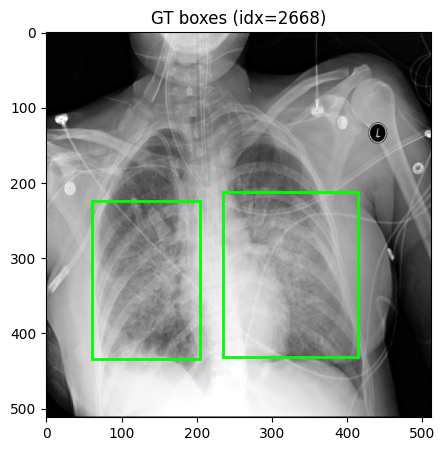

  [TARGET] grid positives=2 out of 256 cells (G=16)
  [TARGET] first positive cell (gj=10, gi=4) ltrb=[ 83.5 112.   60.   98.5]


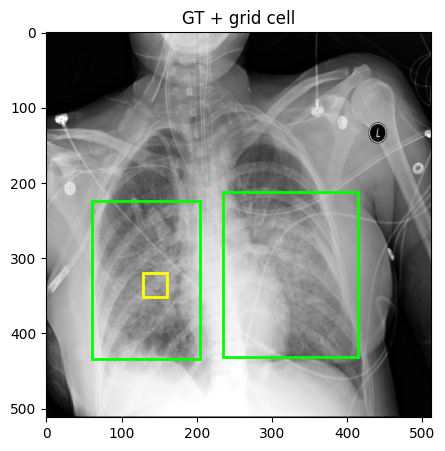


[SAMPLE idx=347] cls=1.0  boxes=1
  boxes min (x1,y1,x2,y2): [113.5 255.5 191.5 331.5]
  boxes max (x1,y1,x2,y2): [113.5 255.5 191.5 331.5]
  ✅ Boxes ضمن حدود الصورة.


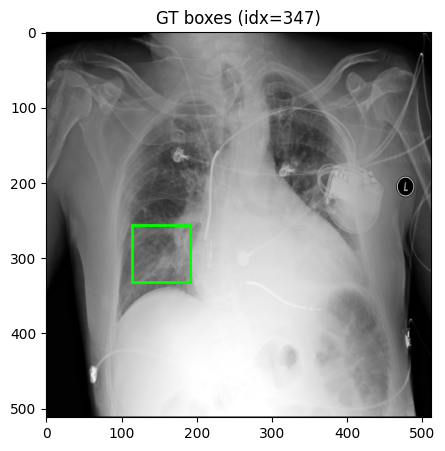

  [TARGET] grid positives=1 out of 256 cells (G=16)
  [TARGET] first positive cell (gj=9, gi=4) ltrb=[30.5 48.5 47.5 27.5]


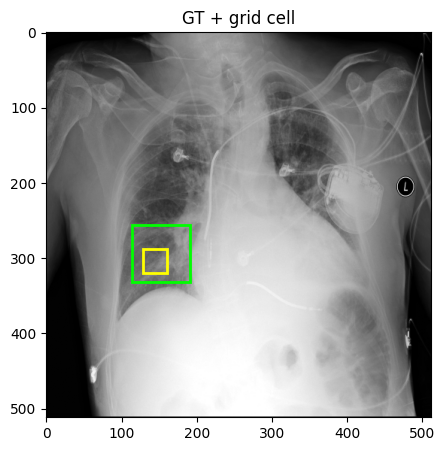


[SAMPLE idx=3173] cls=1.0  boxes=2
  boxes min (x1,y1,x2,y2): [114.5 127.5 228.  336.5]
  boxes max (x1,y1,x2,y2): [306.  289.5 443.  400.5]
  ✅ Boxes ضمن حدود الصورة.


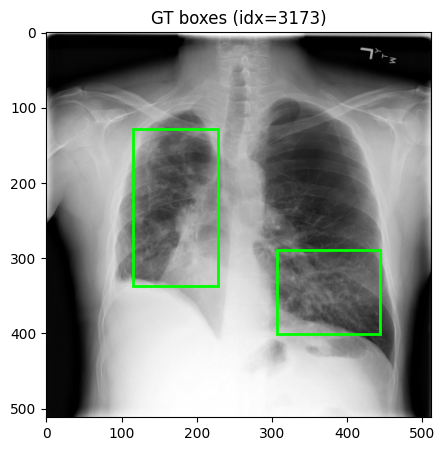

  [TARGET] grid positives=2 out of 256 cells (G=16)
  [TARGET] first positive cell (gj=7, gi=5) ltrb=[ 61.5 112.5  52.   96.5]


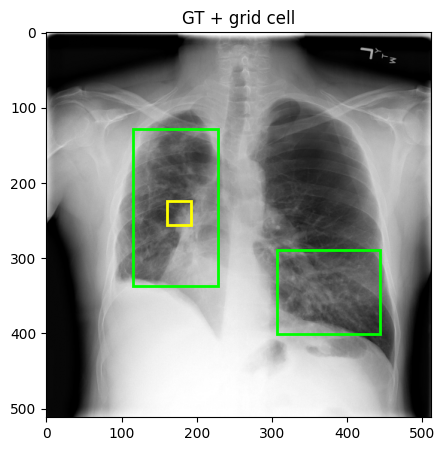


✅ Dataset/Targets sanity check finished.

[PRED] Checking how many boxes are produced at different conf_th ...

[BATCH 0] batch_size=8 positives_in_batch=1
  sample i=7 GT boxes=2
   conf_th=0.5   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.3   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.1   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.05  raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.01  raw_boxes=0   after_nms=0   max_score=0.000


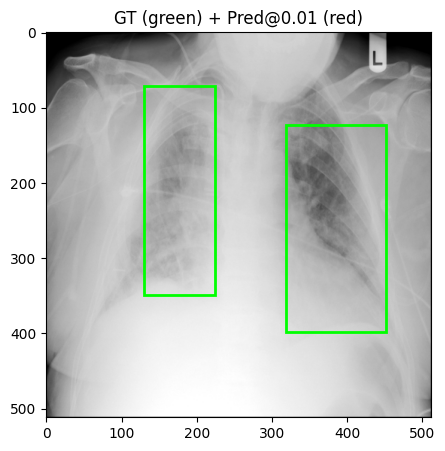


[BATCH 1] batch_size=8 positives_in_batch=2
  sample i=0 GT boxes=1
   conf_th=0.5   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.3   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.1   raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.05  raw_boxes=0   after_nms=0   max_score=0.000
   conf_th=0.01  raw_boxes=1   after_nms=1   max_score=0.011


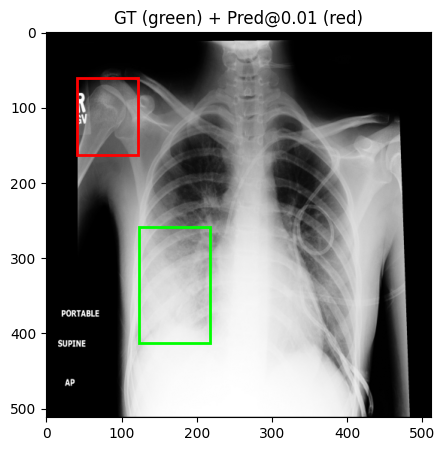


✅ Prediction threshold sanity check finished.


In [ ]:
# =========================================
# Pre-Training Diagnostics for meanIoU=0
# Run this BEFORE training
# =========================================
import numpy as np
import torch
import matplotlib.pyplot as plt

def _draw_boxes(ax, boxes, color=None, label=None):
    # boxes: Nx4 (x1,y1,x2,y2)
    for b in boxes:
        x1,y1,x2,y2 = [float(v) for v in b]
        ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor=color))
    if label:
        ax.set_title(label)

def sanity_check_dataset_and_targets(
    train_ds, val_ds, make_det_targets,
    OUT_SIZE=512, STRIDE=32,
    num_show=3, seed=42
):
    rng = np.random.default_rng(seed)

    # ---------- 1) إحصائيات سريعة ----------
    def count_pos(ds, n=500):
        pos = 0
        for i in range(min(n, len(ds))):
            _, cls, boxes = ds[i]
            if cls.item() == 1:
                pos += 1
        return pos, min(n, len(ds))

    tr_pos, tr_n = count_pos(train_ds)
    va_pos, va_n = count_pos(val_ds)
    print(f"[DATA] Train positives ~ {tr_pos}/{tr_n} ({tr_pos/tr_n:.3f})")
    print(f"[DATA] Val positives   ~ {va_pos}/{va_n} ({va_pos/va_n:.3f})")

    # إذا الـ val positives قليلة جدًا، meanIoU قد يبدو صفري كثيرًا.
    if va_pos == 0:
        print("❌ لا توجد عينات إيجابية في الـ Validation ضمن العينة المفحوصة -> لن يظهر IoU مفيد.")
        return

    # ---------- 2) فحص عيّنات إيجابية: هل الصناديق داخل الحدود؟ ----------
    pos_indices = []
    for i in range(len(val_ds)):
        _, cls, boxes = val_ds[i]
        if cls.item() == 1 and boxes.numel() > 0:
            pos_indices.append(i)

    print(f"[DATA] Found {len(pos_indices)} positive val samples with boxes.")
    if len(pos_indices) == 0:
        print("❌ عينات إيجابية بدون boxes! هذا يعني مشكلة في قراءة CSV أو تجميع boxes_by_pid.")
        return

    pick = rng.choice(pos_indices, size=min(num_show, len(pos_indices)), replace=False).tolist()

    for idx in pick:
        img_t, cls, boxes = val_ds[idx]
        img = img_t.squeeze(0).numpy()
        boxes_np = boxes.numpy()

        # حدود الصناديق
        mn = boxes_np.min(axis=0)
        mx = boxes_np.max(axis=0)
        print(f"\n[SAMPLE idx={idx}] cls={cls.item()}  boxes={len(boxes_np)}")
        print("  boxes min (x1,y1,x2,y2):", mn)
        print("  boxes max (x1,y1,x2,y2):", mx)

        # تحقق هل خارج الصورة
        out_of_bounds = np.any(boxes_np[:, [0,2]] < 0) or np.any(boxes_np[:, [1,3]] < 0) \
                        or np.any(boxes_np[:, [0,2]] > OUT_SIZE) or np.any(boxes_np[:, [1,3]] > OUT_SIZE)
        if out_of_bounds:
            print("  ❌ Boxes خارج حدود الصورة 0..OUT_SIZE -> resize/boxes conversion فيه مشكلة.")
        else:
            print("  ✅ Boxes ضمن حدود الصورة.")

        # رسم
        fig, ax = plt.subplots(figsize=(5,5))
        ax.imshow(img, cmap="gray")
        _draw_boxes(ax, boxes_np, color="lime", label=f"GT boxes (idx={idx})")
        plt.show()

        # ---------- 3) فحص تحويل targets إلى Grid ----------
        obj_t, ltrb_t, pos_mask = make_det_targets(boxes, out_size=OUT_SIZE, stride=STRIDE)
        pos_count = int(pos_mask.sum().item())
        print(f"  [TARGET] grid positives={pos_count} out of {obj_t.numel()} cells (G={OUT_SIZE//STRIDE})")

        if pos_count == 0:
            print("  ❌ pos_mask=0 -> مشكلة في make_det_targets (مثلاً stride/out_size أو centers خارج grid).")
        else:
            # اطبع أول خلية إيجابية
            ys, xs = torch.where(pos_mask)
            y0, x0 = int(ys[0].item()), int(xs[0].item())
            ltrb = ltrb_t[:, y0, x0].numpy()
            print(f"  [TARGET] first positive cell (gj={y0}, gi={x0}) ltrb={ltrb}")

            # رسم خلية الشبكة على الصورة
            cell_x1, cell_y1 = x0*STRIDE, y0*STRIDE
            cell_x2, cell_y2 = cell_x1+STRIDE, cell_y1+STRIDE
            fig, ax = plt.subplots(figsize=(5,5))
            ax.imshow(img, cmap="gray")
            _draw_boxes(ax, boxes_np, color="lime", label="GT + grid cell")
            ax.add_patch(plt.Rectangle((cell_x1, cell_y1), STRIDE, STRIDE, fill=False, linewidth=2, edgecolor="yellow"))
            plt.show()

    print("\n✅ Dataset/Targets sanity check finished.")

def sanity_check_prediction_thresholds(
    model, val_loader,
    decode_boxes, nms,
    OUT_SIZE=512, STRIDE=32,
    conf_list=(0.5, 0.3, 0.1, 0.05, 0.01),
    max_batches=2
):
    model.eval()
    print("\n[PRED] Checking how many boxes are produced at different conf_th ...")
    with torch.no_grad():
        for bi, (imgs, cls_t, boxes_list) in enumerate(val_loader):
            if bi >= max_batches: break
            imgs = imgs.to(device)
            cls_logit, obj_logit, ltrb_pred = model(imgs)

            # اختر فقط الصور الإيجابية في هذا الباتش
            pos_ids = (cls_t.squeeze(1) == 1).nonzero(as_tuple=True)[0].tolist()
            print(f"\n[BATCH {bi}] batch_size={len(imgs)} positives_in_batch={len(pos_ids)}")
            if len(pos_ids) == 0:
                continue

            i = pos_ids[0]  # أول صورة إيجابية
            gt = boxes_list[i]
            print(f"  sample i={i} GT boxes={gt.shape[0]}")

            for conf_th in conf_list:
                boxes_pred, scores = decode_boxes(
                    obj_logit[i].cpu(),
                    ltrb_pred[i].cpu(),
                    out_size=OUT_SIZE, stride=STRIDE, conf_th=conf_th
                )
                nb = int(boxes_pred.shape[0])
                if nb > 0:
                    keep = nms(boxes_pred, scores, iou_th=0.4)
                    boxes_pred = boxes_pred[keep]
                    scores = scores[keep]
                nb2 = int(boxes_pred.shape[0])

                print(f"   conf_th={conf_th:<5} raw_boxes={nb:<3} after_nms={nb2:<3} max_score={(scores.max().item() if nb2>0 else 0):.3f}")

            # رسم على conf منخفض جدًا لمعرفة إن كان يخرج شيء
            conf_th = conf_list[-1]
            boxes_pred, scores = decode_boxes(
                obj_logit[i].cpu(),
                ltrb_pred[i].cpu(),
                out_size=OUT_SIZE, stride=STRIDE, conf_th=conf_th
            )
            if boxes_pred.numel() > 0:
                keep = nms(boxes_pred, scores, iou_th=0.4)
                boxes_pred = boxes_pred[keep]
                scores = scores[keep]

            img = imgs[i].detach().cpu().squeeze(0).numpy()
            fig, ax = plt.subplots(figsize=(5,5))
            ax.imshow(img, cmap="gray")
            if gt.numel() > 0:
                _draw_boxes(ax, gt.numpy(), color="lime", label=f"GT (green) + Pred@{conf_th} (red)")
            if boxes_pred.numel() > 0:
                _draw_boxes(ax, boxes_pred.numpy(), color="red")
            plt.show()

    print("\n✅ Prediction threshold sanity check finished.")

# ======= Run checks =======
sanity_check_dataset_and_targets(
    train_ds, val_ds, make_det_targets,
    OUT_SIZE=OUT_SIZE, STRIDE=STRIDE,
    num_show=3
)

# نموذجك قد يكون غير مهيأ بعد: شغّل بعد تعريف model (حتى لو قبل التدريب) للتأكد من thresholds
try:
    sanity_check_prediction_thresholds(
        model, val_loader,
        decode_boxes, nms,
        OUT_SIZE=OUT_SIZE, STRIDE=STRIDE,
        conf_list=(0.5, 0.3, 0.1, 0.05, 0.01),
        max_batches=2
    )
except NameError:
    print("\n⚠️ model غير معرف بعد. شغّل الجزء الثاني بعد تعريف model مباشرة.")


In [ ]:
import os
import numpy as np
import torch
import gradio as gr
import cv2
from PIL import Image, ImageDraw

# =========================
# 1) Load model checkpoint
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

# اختر أفضل نموذج للتصنيف أو للكشف:
CKPT_PATH = "/content/drive/MyDrive/best_by_auc.pth"  # عدّل المسار

model = MultiTaskNet(in_ch=1, base=32, grid_stride=STRIDE).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# =========================
# 2) Helpers: load PNG/JPG -> نفس preprocessing
# =========================
def read_png_jpg(path: str) -> np.ndarray:
    # اقرأ كـ grayscale لأن نموذجك مدخلاته 1 قناة
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("لم أستطع قراءة الصورة. تأكد أنها PNG/JPG صالحة.")
    img = img.astype(np.float32)
    img = img / 255.0
    return img

def preprocess_any_input(image_path: str | None, dicom_path: str | None) -> np.ndarray:
    if dicom_path:
        img = read_dicom(dicom_path)   # يرجع 0..1
    elif image_path:
        img = read_png_jpg(image_path) # 0..1
    else:
        raise ValueError("ارفع صورة PNG/JPG أو ملف DICOM.")

    # resize إلى OUT_SIZE x OUT_SIZE (نفس مشروعك)
    img = cv2.resize(img, (OUT_SIZE, OUT_SIZE), interpolation=cv2.INTER_LINEAR)
    return img

def draw_boxes_on_image(img01: np.ndarray, boxes_xyxy: np.ndarray, scores: np.ndarray, topk=10):
    # img01: grayscale 0..1
    img255 = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    pil = Image.fromarray(img255).convert("RGB")
    draw = ImageDraw.Draw(pil)

    if boxes_xyxy is None or len(boxes_xyxy) == 0:
        return pil

    # خذ أعلى topk
    idx = np.argsort(-scores)[:topk]
    for i in idx:
        x1, y1, x2, y2 = boxes_xyxy[i]
        s = float(scores[i])
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1 + 3, y1 + 3), f"{s:.2f}", fill="red")
    return pil

# =========================
# 3) Inference function
# =========================
@torch.no_grad()
def predict(image_path, dicom_file, conf_th=0.3, iou_th=0.4):
    # Gradio File component يعطي filepath إذا type="filepath" :contentReference[oaicite:2]{index=2}
    dicom_path = None
    if dicom_file is not None:
        # dicom_file قد يكون str (filepath) أو object له .name حسب السياق
        dicom_path = dicom_file if isinstance(dicom_file, str) else getattr(dicom_file, "name", None)

    img = preprocess_any_input(image_path, dicom_path)
    x = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)  # 1x1xH xW

    cls_logit, obj_logit, ltrb_pred = model(x)
    cls_prob = float(torch.sigmoid(cls_logit)[0, 0].item())

    boxes_pred, scores = decode_boxes(
        obj_logit[0].detach().cpu(),
        ltrb_pred[0].detach().cpu(),
        out_size=OUT_SIZE, stride=STRIDE, conf_th=float(conf_th)
    )

    if boxes_pred.numel() > 0:
        keep = nms(boxes_pred, scores, iou_th=float(iou_th))
        boxes_pred = boxes_pred[keep]
        scores = scores[keep]

    # للعرض
    boxes_np = boxes_pred.numpy() if boxes_pred.numel() > 0 else np.zeros((0, 4), dtype=np.float32)
    scores_np = scores.numpy() if scores.numel() > 0 else np.zeros((0,), dtype=np.float32)

    overlay = draw_boxes_on_image(img, boxes_np, scores_np, topk=10)

    # جدول نتائج
    rows = []
    for b, s in zip(boxes_np.tolist(), scores_np.tolist()):
        rows.append({"x1": b[0], "y1": b[1], "x2": b[2], "y2": b[3], "score": s})

    label = "Pneumonia (1)" if cls_prob >= 0.5 else "Normal (0)"
    return cls_prob, label, overlay, rows

# =========================
# 4) Gradio UI
# =========================
with gr.Blocks(title="RSNA MultiTask (Classification + Detection)") as demo:
    gr.Markdown("## RSNA Pneumonia — Classification + Detection (from scratch)")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### إدخال PNG/JPG")
            img_in = gr.Image(type="filepath", label="Upload PNG/JPG")  # يرجع filepath :contentReference[oaicite:3]{index=3}

        with gr.Column(scale=1):
            gr.Markdown("### أو إدخال DICOM")
            dcm_in = gr.File(
                label="Upload DICOM (.dcm/.dicom)",
                file_types=[".dcm", ".dicom"],
                type="filepath"
            )  # file_types/type موثقة هنا :contentReference[oaicite:4]{index=4}

    with gr.Row():
        conf = gr.Slider(0.05, 0.95, value=0.30, step=0.05, label="Detection confidence threshold")
        iou  = gr.Slider(0.10, 0.90, value=0.40, step=0.05, label="NMS IoU threshold")

    btn = gr.Button("Run inference")

    with gr.Row():
        prob_out = gr.Number(label="P(pneumonia)")
        label_out = gr.Textbox(label="Predicted label")

    overlay_out = gr.Image(label="Overlay (boxes)")
    table_out = gr.Dataframe(label="Detected boxes", interactive=False)

    btn.click(
        fn=predict,
        inputs=[img_in, dcm_in, conf, iou],
        outputs=[prob_out, label_out, overlay_out, table_out]
    )

demo.launch(debug=True)


NameError: name 'MultiTaskNet' is not defined

In [ ]:
!pip -q install onnx onnxscript onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np

# نفس تعريف الموديل MultiTaskNet في كودك
model = MultiTaskNet(in_ch=1, base=32, grid_stride=STRIDE)
ckpt = torch.load("/content/rsna_multitask_runs/run1/best_by_auc.pth", map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.eval()

dummy = torch.randn(1, 1, 512, 512)  # B,C,H,W

# تصدير ONNX
torch.onnx.export(
    model,
    dummy,
    "/content/rsna_multitask_runs/rsna_multitask.onnx",
    input_names=["image"],
    output_names=["cls_logit", "obj_logit", "ltrb_pred"],
    dynamic_axes={"image": {0: "batch"}},
    opset_version=17
)

print("Exported rsna_multitask.onnx ✅")


/tmp/ipython-input-4078569400.py:13: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1228 22:45:15.167000 514 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MultiTaskNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MultiTaskNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 26 of general pattern rewrite rules.
Exported rsna_multitask.onnx ✅


In [ ]:
# =========================
# Save PyTorch + ONNX to Google Drive
# =========================
import os, torch



# 3) ملفات الحفظ
PT_PATH  = os.path.join(SAVE_DIR, "rsna_multitask_best.pth")      # PyTorch checkpoint
ONNX_PATH = os.path.join(SAVE_DIR, "rsna_multitask_best.onnx")    # ONNX

print("Saving to:", SAVE_DIR)

# -------------------------------------------------------
# A) حفظ نموذج PyTorch (state_dict)
# -------------------------------------------------------
torch.save({
    "model_state": model.state_dict(),
    "meta": {
        "out_size": 512,
        "stride": STRIDE,
        "note": "MultiTaskNet (cls + det), ltrb in stride-units; decode uses *stride"
    }
}, PT_PATH)

print("✅ Saved PyTorch checkpoint ->", PT_PATH)

# -------------------------------------------------------
# B) تصدير ONNX وحفظه في Drive
# -------------------------------------------------------
# تأكد أن الحزم موجودة
!pip -q install onnx onnxscript

model.eval()
dummy = torch.randn(1, 1, 512, 512, device="cpu")

# لو نموذجك على GPU انقله CPU للتصدير (أفضل)
model_cpu = model.to("cpu")

torch.onnx.export(
    model_cpu,
    dummy,
    ONNX_PATH,
    input_names=["image"],
    output_names=["cls_logit", "obj_logit", "ltrb_pred"],
    dynamic_axes={"image": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
    dynamo=False  # يجبر المسار القديم لتجنب مشاكل
)

print("✅ Saved ONNX ->", ONNX_PATH)

# (اختياري) ارجّع الموديل للجهاز السابق
model.to(device)


Saving to: ./rsna_multitask_runs/run1
✅ Saved PyTorch checkpoint -> ./rsna_multitask_runs/run1/rsna_multitask_best.pth


/tmp/ipython-input-3488686165.py:40: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ Saved ONNX -> ./rsna_multitask_runs/run1/rsna_multitask_best.onnx


MultiTaskNet(
  (stem): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
  )
  (down1): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (a